In [ ]:
!pip install yfinance fredapi pandas_market_calendars numpy pandas scipy scikit-learn xgboost matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.4/131.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from fredapi import Fred
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error
#from sklearn.preprocessing import LabelEncoder
import os
from scipy.optimize import minimize
from datetime import datetime, timedelta, date
import pandas_market_calendars as mcal

In [ ]:
"""
import yfinance as yf
import numpy as np
import pandas as pd
from fredapi import Fred
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import os
import kagglehub
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
path = kagglehub.dataset_download("vladtasca/fomc-meeting-statements-and-minutes")

print("Path to dataset files:", path)
csv_path = os.path.join(path, 'communications.csv')
df_mp = pd.read_csv(csv_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

def predict_sentiment_with_score(texts, batch_size=64):
    model.eval()
    sentiments = []
    scores = []
    probs_all = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encodings = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

        with torch.no_grad():
            outputs = model(**encodings)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=1)
            tone_score = probs[:, 2] - probs[:, 0]

            probs_all.extend(probs.cpu().numpy())
            sentiments.extend(preds.cpu().numpy())
            scores.extend(tone_score.cpu().numpy())

    return np.array(sentiments), np.array(scores), np.array(probs_all)

csv_path = os.path.join(path, 'communications.csv')
df_mp = pd.read_csv(csv_path)

df_mp = df_mp[df_mp['Type'] == 'Statement'].copy()

sentiments, tone_scores, probs = predict_sentiment_with_score(df_mp['Text'].astype(str).tolist())

df_mp['sentiment_class'] = sentiments
df_mp['tone_score'] = tone_scores
df_mp['prob_negative'] = probs[:, 0]
df_mp['prob_neutral'] = probs[:, 1]
df_mp['prob_positive'] = probs[:, 2]

label_map = {0: "positive", 1: "negative", 2: "neutral"}
df_mp['sentiment_class'] = df_mp['sentiment_class'].map(label_map)

print(df_mp['sentiment_class'].value_counts())

df_mp = df_mp.sort_values('Release Date')

exp_mean = df_mp['tone_score'].expanding().mean()
exp_std  = df_mp['tone_score'].expanding().std().replace(0, 1e-12)

df_mp['tone_z'] = (df_mp['tone_score'] - exp_mean) / exp_std

daily_tone = df_mp.groupby('Release Date')['tone_z'].mean().reset_index()
daily_tone = daily_tone.rename(columns={'tone_z': 'avg_tone_z'})

daily_tone.to_csv("fomc_tone_daily.csv", index=False)
df_mp.to_csv('sentiment_mp.csv', index=False)
"""

"""
import requests
import yaml
import re
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification,AutoModelForMaskedLM, Trainer, TrainingArguments,  DataCollatorForLanguageModeling
import torch
import numpy as np
import pandas as pd
from ftfy import fix_text

import pandas as pd

df = pd.read_csv("news_train_only.csv")
df['newsDatetime'] = pd.to_datetime(df['newsDatetime'])
df['title'] = df['title'].apply(lambda x: fix_text(str(x)))
df = df[df["important"] >= 1]



import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForMaskedLM
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


cls_path = "./"
tokenizer = AutoTokenizer.from_pretrained(cls_path)
cls_model = AutoModelForSequenceClassification.from_pretrained(cls_path).to(device)


mlm_path = "./sample_data"
mlm_model = AutoModelForMaskedLM.from_pretrained(mlm_path)
mlm_state = mlm_model.bert.state_dict()

filtered_state = {k: v for k, v in mlm_state.items()
                  if not k.startswith("pooler")}



print("✓ Successfully merged DAPT encoder into classification model.")


save_path = "./crypto_finbert_final"
cls_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"✓ Final crypto FinBERT saved to: {save_path}")

model_name = "./crypto_finbert_final"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

def predict_sentiment_with_score(texts, batch_size=64):
    model.eval()
    sentiments = []
    scores = []
    probs_all = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encodings = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

        with torch.no_grad():
            outputs = model(**encodings)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=1)
            tone_score = probs[:, 2] - probs[:, 0]

            probs_all.extend(probs.cpu().numpy())
            sentiments.extend(preds.cpu().numpy())
            scores.extend(tone_score.cpu().numpy())

    return np.array(sentiments), np.array(scores), np.array(probs_all)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sentiments, tone_scores, probs = predict_sentiment_with_score(df['title'].astype(str).tolist())

df['sentiment_class'] = sentiments
df['tone_score'] = tone_scores
df['prob_negative'] = probs[:, 0]
df['prob_neutral'] = probs[:, 1]
df['prob_positive'] = probs[:, 2]
print(df['sentiment_class'].value_counts())

df = df.sort_values('newsDatetime')

exp_mean = df['tone_score'].expanding().mean()
exp_std  = df['tone_score'].expanding().std().replace(0, 1e-12)

df['tone_z'] = (df['tone_score'] - exp_mean) / exp_std
daily_tone = df.groupby('newsDatetime')['tone_z'].mean().reset_index()
daily_tone = daily_tone.rename(columns={'tone_z': 'avg_tone_z'})
daily_tone.to_csv("crypto_daily.csv", index=False)
df.to_csv('sentiment_crypto.csv', index=False)
"""

'\nimport requests\nimport yaml\nimport re\nfrom datasets import Dataset\nfrom transformers import AutoTokenizer, AutoModelForSequenceClassification,AutoModelForMaskedLM, Trainer, TrainingArguments,  DataCollatorForLanguageModeling\nimport torch\nimport numpy as np\nimport pandas as pd\nfrom ftfy import fix_text\n\nimport pandas as pd\n\ndf = pd.read_csv("news_train_only.csv")\ndf[\'newsDatetime\'] = pd.to_datetime(df[\'newsDatetime\'])\ndf[\'title\'] = df[\'title\'].apply(lambda x: fix_text(str(x)))\ndf = df[df["important"] >= 1]\n\n\n\nimport torch\nfrom transformers import (\n    AutoTokenizer,\n    AutoModelForSequenceClassification,\n    AutoModelForMaskedLM\n)\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n\ncls_path = "./"\ntokenizer = AutoTokenizer.from_pretrained(cls_path)\ncls_model = AutoModelForSequenceClassification.from_pretrained(cls_path).to(device)\n\n\nmlm_path = "./sample_data"\nmlm_model = AutoModelForMaskedLM.from_pretrained(mlm_path)\n

In [ ]:
start_d = "2018-04-01"
end_d = "2025-04-01"
y_tickers = ['BTC-USD','ETH-USD','XRP-USD','USDT-USD','BNB-USD','DOGE-USD','^GSPC','^CMC200']
y_name = ['BTC','ETH','XRP','USDT','BNB','DOGE','SNP500','crypto_index']
macro_tks = ['M2SL','FEDFUNDS','CPIAUCNS']
m_name = ['M2','FFR','CPI']
api = '6a45878cc17b82e82f8858a004dd82cb'

def get_financial_data(start_d, end_d, y_tickers, macro_tks, re_name1, re_name2, api):
    nyse = mcal.get_calendar('NYSE')
    raw_index = nyse.schedule(start_date=start_d, end_date=end_d)
    #index = mcal.date_range(raw_index, frequency='1D').tz_convert(None).normalize()
    index = pd.date_range(start=start_d, end=end_d, freq="D")
    monthly_index = pd.date_range(start="2018-03-01", end="2025-05-01", freq="MS") ####MS

    fred = Fred(api_key=api)
    asset_price = pd.DataFrame(index=index, columns=re_name1)
    f_macro = pd.DataFrame(index=monthly_index, columns=re_name2)
    asset_open = pd.DataFrame(index=index, columns=re_name1)

    for t,y in zip(y_tickers,re_name1):
        price = yf.download(t, start=start_d, end=end_d, auto_adjust=True)
        asset_price[y] = price['Close']

    for t,y in zip(y_tickers,re_name1):
        price = yf.download(t, start=start_d, end="2025-04-09", auto_adjust=True)
        asset_open[y] = price['Open']

    for m, r in zip(macro_tks, re_name2):
        m = fred.get_series(m, start_d, end_d).to_frame(name=r)
        f_macro[r] = m[r]

    f_macro = f_macro.shift(1)
    #asset_price['crypto_index'] = asset_price['crypto_index'].fillna(0)
    #asset_open['crypto_index'] = asset_open['crypto_index'].fillna(0)
    asset_price = asset_price.ffill()
    asset_open = asset_open.ffill()
    asset_open.iloc[-1] = np.nan
    return asset_price, f_macro, asset_open

asset_price, f_macro, asset_open = get_financial_data(start_d, end_d, y_tickers, macro_tks, y_name,m_name, api) # Asstes, indices and macro


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [ ]:
def close_log_return(df_1,df_2):

    df_1_log = np.log(df_1 / df_1.shift(1))
    df_2_log = np.log(df_2)
    return df_1_log, df_2_log

log_asset_p, log_f_macro = close_log_return(asset_price, f_macro)

In [ ]:
"""
These notebook cells build a **GARCH-MIDAS volatility model** enhanced with sentiment and macroeconomic data.
It integrates monthly M2 money supply and daily sentiment indices to predict crypto volatility
We aim to test whether adding sentiment information improves volatility forecasting compared to a baseline macro model.
"""
# --- 1. Data Preparation: Returns and Sentiment ---

from scipy.stats import zscore
from scipy.stats import norm

path_1 = 'sentiment_crypto.csv' # Sentiment Results
path_2 = 'sentiment_mp.csv'

def data_load(*path):
    crypto_s = pd.read_csv(path_1)
    daily_avg_mp = pd.read_csv(path_2)

    daily_avg_mp['date'] = pd.to_datetime(daily_avg_mp['Release Date'], dayfirst=True)
    daily_avg_mp['date'] = daily_avg_mp["date"].dt.strftime("%m/%d/%Y")
    daily_avg_mp['date'] = pd.to_datetime(daily_avg_mp['date'])
    daily_avg_mp['average_sentiment'] = daily_avg_mp['tone_z']
    mp_df  = daily_avg_mp.set_index('date')
    mp_df  = mp_df['average_sentiment'].resample('M').mean().loc['2018-04-01': '2025-04-01']
    mp_df = mp_df.ffill()
    crypto_s['tone_z'] =((crypto_s['tone_score'] * crypto_s['important']) - (crypto_s['tone_score'] * crypto_s['important']).mean()) / (crypto_s['tone_score'] * crypto_s['important']).std()
    crypto_s = pd.concat([
        crypto_s['date'].rename('date'),
        crypto_s['tone_z'].rename('tone_z')
    ], axis=1).dropna()

    crypto_s["date"] = pd.to_datetime(crypto_s["date"], dayfirst=True).dt.strftime("%m/%d/%Y")
    crypto_s['date'] = pd.to_datetime(crypto_s['date'])
    crypto_s['date'] = crypto_s['date'].dt.date
    daily_tone = (
        crypto_s.groupby('date')
        .agg(avg_tone_z=('tone_z', 'mean'),
             n_articles=('tone_z', 'count'))
        .reset_index()
    )

    daily_avg_sentiment = daily_tone
    daily_avg_sentiment['date'] = pd.to_datetime(daily_avg_sentiment['date'])
    sentiment_c = daily_avg_sentiment.resample('M', on='date')['avg_tone_z'].mean().loc['2018-04-01': '2025-04-01']
    mp_df = mp_df.reindex(sentiment_c.index)
    sentiment_c = sentiment_c.to_frame()
    mp_df = mp_df.to_frame()
    mp_df = mp_df.rename(columns={mp_df.columns[0]: 'mp_sen'})

    sentiment_c = sentiment_c.rename(columns={sentiment_c.columns[0]: 'crypto_sen'})
    sentiments = pd.concat([
    sentiment_c['crypto_sen'],
    mp_df['mp_sen']
    ], axis=1).dropna()

    return daily_avg_mp, sentiments

daily_avg_mp, sentiments = data_load(path_1, path_2) # Crypto Sentiment & Monetary Policy Sentiment


/tmp/ipython-input-1002497569.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mp_df  = mp_df['average_sentiment'].resample('M').mean().loc['2018-04-01': '2025-04-01']
/tmp/ipython-input-1002497569.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sentiment_c = daily_avg_sentiment.resample('M', on='date')['avg_tone_z'].mean().loc['2018-04-01': '2025-04-01']


In [ ]:

garch_tickers = ['BTC','ETH','XRP','USDT','BNB','DOGE']
midas_tickers = ['M2','FFR','CPI']


def garch_midas_df(garch_df, midas_df, ticker1, ticker2):
    cols1 = [t1 for t1 in ticker1 if t1 in garch_df.columns]
    garch_df_1 = garch_df[cols1]
    cols2 = [t1 for t1 in garch_df.columns if t1 not in ticker1]
    midas_df_1 =  garch_df[cols2].resample('M').mean()

    monthly_dict = {}
    for t2 in ticker2:
        if t2 in midas_df.columns:
            monthly_dict[t2] = midas_df[t2].resample('M').mean()
    midas_df_2 = pd.DataFrame(monthly_dict)

    midas_df = pd.concat([midas_df_2, midas_df_1], axis=1)

    return garch_df_1, midas_df

garch_df, midas_df_og = garch_midas_df(log_asset_p, log_f_macro, garch_tickers, midas_tickers) # GARCH Data & MIDAS Data

def cdf_midas(*midas_df):
    results = []

    for df in midas_df:
        log_df = df.pct_change()
        z_df = log_df.copy()

        for col in log_df.columns:
            series = log_df[col]
            rolling_mean = series.expanding().mean()
            rolling_std = series.expanding().std().replace(0, 1e-12)
            z_df[col] = (series - rolling_mean) / rolling_std

        cdf_df = z_df.apply(lambda s: norm.cdf(s))

        results.append(cdf_df)

    return results

midas_df = cdf_midas(midas_df_og)[0] #


/tmp/ipython-input-2999516917.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  midas_df_1 =  garch_df[cols2].resample('M').mean()
/tmp/ipython-input-2999516917.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_dict[t2] = midas_df[t2].resample('M').mean()
/tmp/ipython-input-2999516917.py:27: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  log_df = df.pct_change()


In [ ]:
from scipy.stats import skew, kurtosis

def summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    out = pd.DataFrame(index=df.columns)
    out["Mean"] = df.mean()
    out["Std"]  = df.std(ddof=1)
    out["Skewness"] = df.apply(lambda s: skew(s.dropna(), bias=False))
    out["Kurtosis"] = df.apply(lambda s: kurtosis(s.dropna(), fisher=True, bias=False))  # excess kurtosis

    out["N"] = df.count()
    return out.round(4)

garch_df_stats = garch_df.dropna()
midas_df_stats = midas_df.dropna()
return_stats_g = summary_stats(garch_df_stats)
return_stats_m = summary_stats(midas_df_stats)
print(return_stats_g)
print(return_stats_m)

        Mean     Std  Skewness  Kurtosis     N
BTC   0.0010  0.0341   -0.9914   16.2128  2557
ETH   0.0006  0.0446   -0.9877   12.4984  2557
XRP   0.0006  0.0534    0.5937   18.0846  2557
USDT -0.0000  0.0030    0.3399   83.6773  2557
BNB   0.0016  0.0461   -0.1807   20.0566  2557
DOGE  0.0016  0.0674    5.4400  112.5336  2557
                Mean     Std  Skewness  Kurtosis   N
M2            0.4341  0.2417    0.9304    0.2618  67
FFR           0.4257  0.1825   -0.1411    2.4560  67
CPI           0.5760  0.2971   -0.1269   -1.2639  67
SNP500        0.5085  0.1201   -0.2421    7.7924  67
crypto_index  0.4722  0.2553    0.3495   -0.3228  67


In [ ]:
# Train/Validation Split
idx_1_train = int(len(garch_df.index) * 0.75)
idx_2_train = int(len(midas_df.index) * 0.75)
idx_3_train = int(len(sentiments.index) * 0.75)
garch_train = garch_df.iloc[:idx_1_train]
garch_valid = garch_df.iloc[idx_1_train:]
midas_train = midas_df.iloc[:idx_2_train]
midas_valid = midas_df.iloc[idx_2_train:]
sentiments_train = sentiments.iloc[:idx_3_train]
sentiments_valid = sentiments.iloc[idx_3_train:]

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [ ]:
from scipy.optimize import dual_annealing
def compute_tau_param(macro_series, theta1, theta2, K):
    k = np.arange(1, K+1)
    weights = np.exp(theta1 * k + theta2 * (k**2))
    weights = weights / weights.sum()

    tau = []
    for t in range(K, len(macro_series)):
        lagged = macro_series.iloc[t-K:t].values[::-1]
        tau_t = np.exp(np.dot(weights, lagged))
        tau.append(tau_t)

    idx = macro_series.index[K:]
    return pd.Series(tau, index=idx)

def compute_g_param(returns, tau_series, omega, alpha, beta):
    eps = 1e-12
    returns = returns.mean(axis=1).reindex(tau_series.index)
    eps2 = returns**2

    scale = eps2.rolling(60, min_periods=1).mean().fillna(eps2.expanding().mean())

    g = [1.0]
    for t in range(1, len(eps2)):
        eps_std = eps2.iloc[t-1] / (scale.iloc[t-1] + eps)
        g_t = omega + alpha * eps_std + beta * g[-1]
        g.append(g_t)

    return pd.Series(g, index=tau_series.index)

def neg_loglik(params, returns, macro_series, K=10*30):

    theta1, theta2, omega, alpha, beta = params


    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10

    tau = compute_tau_param(macro_series, theta1, theta2, K)
    g = compute_g_param(returns, tau, omega, alpha, beta)

    sigma2 = tau * g
    r = returns.mean(axis=1).reindex(sigma2.index)

    ll = -0.5 * np.sum(np.log(sigma2) + (r**2)/sigma2)

    return -ll   # minimize negative likelihood

midas_train_1 = midas_train.resample('D').ffill().reindex(garch_train.index)
midas_valid_1 = midas_valid.resample('D').ffill().reindex(garch_valid.index)
X_train, X_test, y_train, y_test = train_test_split(midas_train_1,garch_train, test_size=0.25, random_state=42, shuffle=False)

init_params = np.array([0.3, -0.5, 0.01, 0.1, 0.8])
bounds = [
    (-2.5, 1.5),     # theta1
    (-10, -1e-3),    # theta2
    (1e-8, 0.5),     # omega
    (1e-5, 0.3),     # alpha
    (0.45, 0.99)      # beta
]

sa_res = dual_annealing(
    neg_loglik,
    bounds=bounds,
    args=(y_train, X_train['M2'], 30*6),
    maxiter=60,
    seed=42
)
res = minimize(
    neg_loglik,
    sa_res.x,
    args=(y_train, X_train['M2'], 30*6),
    method='L-BFGS-B',
    bounds = bounds
    )


# simulated annealing

print("Estimated parameters:", res.x)


Estimated parameters: [ 1.50000000e+00 -1.00000000e-03  1.23654926e-05  4.04505438e-05
  9.33149707e-01]


In [ ]:
theta1, theta2, omega, alpha, beta = res.x

print("theta1 =", theta1)
print("theta2 =", theta2)
print("omega  =", omega)
print("alpha  =", alpha)
print("beta   =", beta)

theta1 = 1.5
theta2 = -0.001
omega  = 1.2365492598624556e-05
alpha  = 4.045054382764351e-05
beta   = 0.9331497072657494


In [ ]:
def exponential_almon_weights(theta1, theta2, K):
    k = np.arange(1, K + 1)
    raw = np.exp(theta1 * k + theta2 * k**2)
    return raw / raw.sum()

def compute_tau_series(macro_series, theta1, theta2, K):
    k = np.arange(1, K+1)
    weights = np.exp(theta1 * k + theta2 * k**2)
    weights = weights / weights.sum()

    tau = []
    for t in range(K, len(macro_series)):
        lagged = macro_series.iloc[t-K:t].values[::-1]
        tau_t = np.exp(np.dot(weights, lagged))
        tau.append(tau_t)

    idx = macro_series.index[K:]
    return pd.Series(tau, index=idx)


tau_series = compute_tau_series(X_train['M2'], theta1, theta2, K=6*30)
tau_series_t = compute_tau_series(X_test['M2'], theta1, theta2, K=6*30)
"""
The MIDAS component uses a distributed lag structure with exponential Almon weights
to capture the long-term impact of macro variables on volatility.
"""

'\nThe MIDAS component uses a distributed lag structure with exponential Almon weights\nto capture the long-term impact of macro variables on volatility.\n'

In [ ]:

"""
We normalize macro variables to improve stability and interpretability, then build the MIDAS term (τₜ) as a smoothed macroeconomic factor.
"""
# --- 4. Short-term Volatility: GARCH(1,1) component ---
garch_dict = {'omega':omega, 'alpha': alpha, 'beta': beta}

def garch_midas_cal(returns,tau_series, garch_dict):
    omega = garch_dict['omega']
    alpha = garch_dict['alpha']
    beta  = garch_dict['beta']
    eps = 1e-12

    tau_daily = tau_series
    returns = returns.mean(axis=1).reindex(tau_daily.index)

    eps2_base  = returns ** 2
    scale_base = eps2_base.rolling(60, min_periods=1).mean()
    scale_base = scale_base.fillna(eps2_base.expanding().mean()).fillna(eps2_base.iloc[0])

    g = [1.0]
    for t in range(1, len(eps2_base)):
        eps_std = eps2_base.iloc[t-1] / (scale_base.iloc[t-1] + eps)
        g_t = omega + alpha * eps_std + beta * g[-1]
        g.append(g_t)

    g = pd.Series(g, index=tau_daily.index)
    sigma2 = tau_daily * g
    sigma = np.sqrt(sigma2)

    return sigma2, sigma, g, returns

sigma2, sigma, g, returns = garch_midas_cal(y_train, tau_series, garch_dict)
sigma2_t, sigma_t, g_t, returns_t = garch_midas_cal(y_test, tau_series_t, garch_dict)

"""
The GARCH(1,1) component models short-term volatility clustering, while the MIDAS factor adjusts long-term volatility levels.
Together, they form the GARCH-MIDAS structure σₜ² = τₜ × gₜ.
"""


'\nThe GARCH(1,1) component models short-term volatility clustering, while the MIDAS factor adjusts long-term volatility levels.\nTogether, they form the GARCH-MIDAS structure σₜ² = τₜ × gₜ.\n'

In [ ]:
# MIDAS_DF = ['M2', 'FFR', 'CPI', 'SNP500', 'crypto_index']
# SENTIMENT_DF = ['crypto_sen','mp_sen']

feat_names_1 = []
feat_names_2 = ['M2']

sen_names_1 = ['crypto_sen','mp_sen']
sen_names_2 = ['crypto_sen']



def multi_midas_feature_w_ridge(midas_df, returns, sentiments, feat_names, sen_names, instruct): # instruct = 1 for Ridge, else for RandomForest
    midas_df = midas_df[feat_names]
    sentiments = sentiments[sen_names]
    returns = returns.mean(axis=1)
    returns.name = 'mean_returns'
    midas_df_new = pd.concat([midas_df, sentiments], axis=1) # New MIDAS df
    midas_df_new = midas_df_new.resample('D').ffill().reindex(returns.index)
    aligned_data = pd.concat([midas_df_new, returns], axis=1).dropna()
    midas_df_aligned = aligned_data[midas_df_new.columns]
    returns_aligned = aligned_data[returns.name]

    X_train, X_test, y_train, y_test = train_test_split(midas_df_aligned, returns_aligned, test_size=0.25, random_state=42, shuffle=False)
    returns_train = y_train
    midas_train_split = X_train
    returns_test = y_test
    midas_test_split = X_test

    if instruct == 1:
        alphas_ridge = np.logspace(-3, 3, 100)
        ridge_cv = RidgeCV(alphas_ridge, store_cv_values=False)
        ridge_cv.fit(X_train, y_train**2)
        weights = ridge_cv.coef_

    elif instruct == 2:
        alphas_lasso = np.logspace(-3, 3, 100)
        lasso_cv = LassoCV(alphas=alphas_lasso)
        lasso_cv.fit(X_train, y_train**2)
        weights = lasso_cv.coef_

    elif instruct == 0:
        rf_model = RandomForestRegressor(n_estimators=300,
                                       max_leaf_nodes=None,
                                       max_depth=None,
                                       min_samples_leaf=10,
                                       bootstrap=True,
                                       random_state=42, n_jobs=-1)
        rf_model = rf_model.fit(X_train, y_train**2)
        weights = rf_model.feature_importances_

    elif instruct == -1:
        xgb_model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            random_state=42,
            n_jobs=-1
        )

        xgb_model.fit(X_train, y_train**2)
        weights = xgb_model.feature_importances_

    else:
        print("Error, enter any integer from -1 to 2")

    return returns_train, midas_train_split, returns_test, midas_test_split, weights



instruct = 0 # 1 for Ridge, 2 for Lasso, 0 for Random Forest, -1 for XGB

returns_train, midas_df_n_1, returns_test, midas_test_split_1, w_auto_1 = multi_midas_feature_w_ridge(midas_train, garch_train, sentiments_train, feat_names_1, sen_names_1, instruct)

print("Automated weights 1:")
print(pd.Series(w_auto_1, index=list(dict.fromkeys(feat_names_1 +  sen_names_1)), name='weight').round(6))

returns_train, midas_df_n_2, returns_test, midas_test_split_2, w_auto_2 = multi_midas_feature_w_ridge(midas_train, garch_train, sentiments_train, feat_names_2, sen_names_2, instruct)

print("Automated weights 2:")
print(pd.Series(w_auto_2, index=list(dict.fromkeys(feat_names_2 +  sen_names_2)), name='weight').round(6))



Automated weights 1:
crypto_sen    0.514944
mp_sen        0.485056
Name: weight, dtype: float64
Automated weights 2:
M2            0.547081
crypto_sen    0.452919
Name: weight, dtype: float64


In [ ]:
midas_df_new = midas_df_n_1
w = w_auto_1
macro_combo = (midas_df_new @ np.asarray(w)).rename('macro_combo')
init_params = np.array([0.3, -0.5, 0.01, 0.1, 0.8])

sa_res = dual_annealing(
    neg_loglik,
    bounds=bounds,
    args=(y_train, macro_combo, 30*6),
    maxiter=60,
    seed=42
)

res = minimize(
    neg_loglik,
    sa_res.x,
    args=(y_train, macro_combo, 6*30),
    method='L-BFGS-B',
    bounds = [
        (-2.5, 1.5),     # theta1
        (-10, -1e-3),    # theta2
        (1e-8, 0.5),     # omega
        (1e-5, 0.3),     # alpha
        (0.45, 0.99)      # beta
    ]
    )


theta1_1, theta2_1, omega_1, alpha_1, beta_1 = res.x

print("theta1 =", theta1_1)
print("theta2 =", theta2_1)
print("omega  =", omega_1)
print("alpha  =", alpha_1)
print("beta   =", beta_1)

garch_midas_dict_1 = {"theta1": theta1_1, "theta2": theta2_1,'omega':omega_1, 'alpha': alpha_1, 'beta': beta_1}

theta1 = 0.10264899570839017
theta2 = -0.0010034622619855358
omega  = 0.0006514070138703113
alpha  = 0.000144702736506349
beta   = 0.45


In [ ]:
midas_df_new = midas_df_n_2
w = w_auto_2
macro_combo = (midas_df_new @ np.asarray(w)).rename('macro_combo')
init_params = np.array([0.3, -0.5, 0.01, 0.1, 0.8])

sa_res = dual_annealing(
    neg_loglik,
    bounds=bounds,
    args=(y_train, macro_combo, 30*6),
    maxiter=60,
    seed=42
)

res = minimize(
    neg_loglik,
    sa_res.x,
    args=(y_train, macro_combo, 6*30),
    method='L-BFGS-B',
    bounds = [
        (-2.5, 1.5),     # theta1
        (-10, -1e-3),    # theta2
        (1e-8, 0.5),     # omega
        (1e-5, 0.3),     # alpha
        (0.45, 0.99)      # beta
    ]
    )


theta1_2, theta2_2, omega_2, alpha_2, beta_2 = res.x

print("theta1 =", theta1_2)
print("theta2 =", theta2_2)
print("omega  =", omega_2)
print("alpha  =", alpha_2)
print("beta   =", beta_2)

garch_midas_dict_2 = {"theta1": theta1_2, "theta2": theta2_2,'omega':omega_2, 'alpha': alpha_2, 'beta': beta_2}

theta1 = 1.5
theta2 = -0.11542183178252277
omega  = 0.000429193293781696
alpha  = 0.00011849124444817648
beta   = 0.45


In [ ]:
def build_sigma2_from_weights(w, returns, midas_df_new,garch_midas_dict):

    eps = 1e-12
    omega = garch_midas_dict['omega']
    alpha = garch_midas_dict['alpha']
    beta  = garch_midas_dict['beta']
    theta1 = garch_midas_dict['theta1']
    theta2 = garch_midas_dict['theta2']
    K = 6*30

    macro_combo = (midas_df_new @ np.asarray(w)).rename('macro_combo')

    tau_series = compute_tau_series(macro_combo, theta1=theta1, theta2=theta2, K=K)
    tau_daily = tau_series.resample('D').ffill().reindex(returns.index).dropna()
    returns = returns.loc[tau_daily.index]
    eps2_base  = returns**2
    scale_base = eps2_base.rolling(60, min_periods=1).mean()
    scale_base = scale_base.fillna(eps2_base.expanding().mean()).fillna(eps2_base.iloc[0]) #scale_base.fillna(eps2_base.expanding().mean().shift(1)).fillna(eps2_base.iloc[0])

    g2_list = [1.0]
    for t in range(1, len(returns)):
        eps_std = eps2_base.iloc[t-1] / (scale_base.iloc[t-1] + eps)
        g_t = omega + alpha * eps_std + beta * g2_list[-1]
        g2_list.append(g_t)
    g2 = pd.Series(g2_list, index=returns.index, name='g2')
    sigma2_s = (tau_daily * g2).clip(lower=eps)
    sigma_s = np.sqrt(sigma2_s)

    return sigma2_s, sigma_s, g2

sigma2_s, sigma_s, g2 = build_sigma2_from_weights(w_auto_1, returns_train, midas_df_n_1,garch_midas_dict_1) # Train
sigma2_ext, sigma_ext, g_ext = build_sigma2_from_weights(w_auto_2, returns_train, midas_df_n_2,garch_midas_dict_2) # Train
common_idx = sigma_s.index.intersection(sigma_ext.index)
common_idx = sigma.index.intersection(common_idx)
sigma_s = sigma_s.loc[common_idx]
sigma_ext = sigma_ext.loc[common_idx]
sigma = sigma.loc[common_idx]


In [ ]:
# Test
sigma2_s_t, sigma_s_t, g2_t = build_sigma2_from_weights(w_auto_1, returns_test, midas_test_split_1,garch_midas_dict_1)
sigma2_ext_t, sigma_ext_t, g_ext_t = build_sigma2_from_weights(w_auto_2, returns_test, midas_test_split_2,garch_midas_dict_2)
common_idx = sigma_s_t.index.intersection(sigma_ext_t.index)
common_idx = sigma_t.index.intersection(common_idx)
sigma_s_t = sigma_s_t.loc[common_idx]
sigma_ext_t = sigma_ext_t.loc[common_idx]
sigma_t = sigma_t.loc[common_idx]

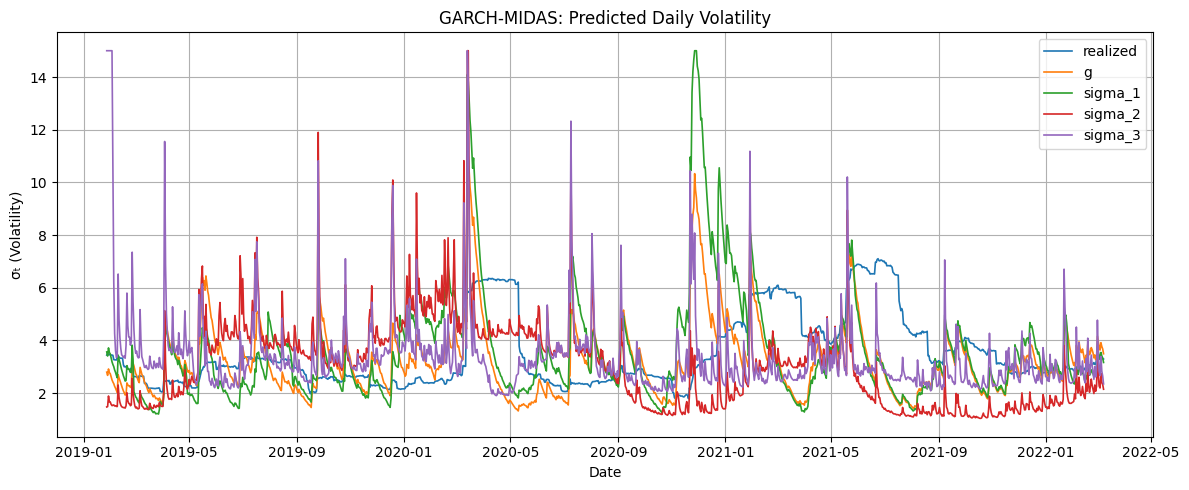

In [ ]:
# --- 7. Visualization of Volatility Forecasts ---
# sigma_1, sigma_2, sigma_3 = baseline_sigma, base + crypto_sen, extended midas
import matplotlib.pyplot as plt

def garch_midas_visual(garch_df, g, *sigmas):
    returns = garch_df.mean(axis=1)
    realized = returns.rolling(60).std()
    idx = realized.index.intersection(g.index)
    c = g.mean() / realized.loc[idx].mean()
    realized_scaled = realized

    sigma_df = {"realized": realized_scaled,
               "g":g}

    for c,s in enumerate(sigmas, start=1):
        colname = f"sigma_{c}"
        sigma_df[colname] = s.reindex(idx)

    df_plt = pd.DataFrame(sigma_df).dropna()


    scale = 3.0 / df_plt.quantile(0.5)
    df_scaled = df_plt.mul(scale, axis=1).clip(0, 15)
    plt.figure(figsize=(12, 5))

    for c in df_scaled.columns:
        plt.plot(df_scaled.index, df_scaled[c], label=c, linewidth=1.2)

    plt.title("GARCH-MIDAS: Predicted Daily Volatility")
    plt.xlabel("Date")
    plt.ylabel("σₜ (Volatility)")
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()


garch_midas_visual(y_train, g, sigma2, sigma2_s, sigma2_ext)

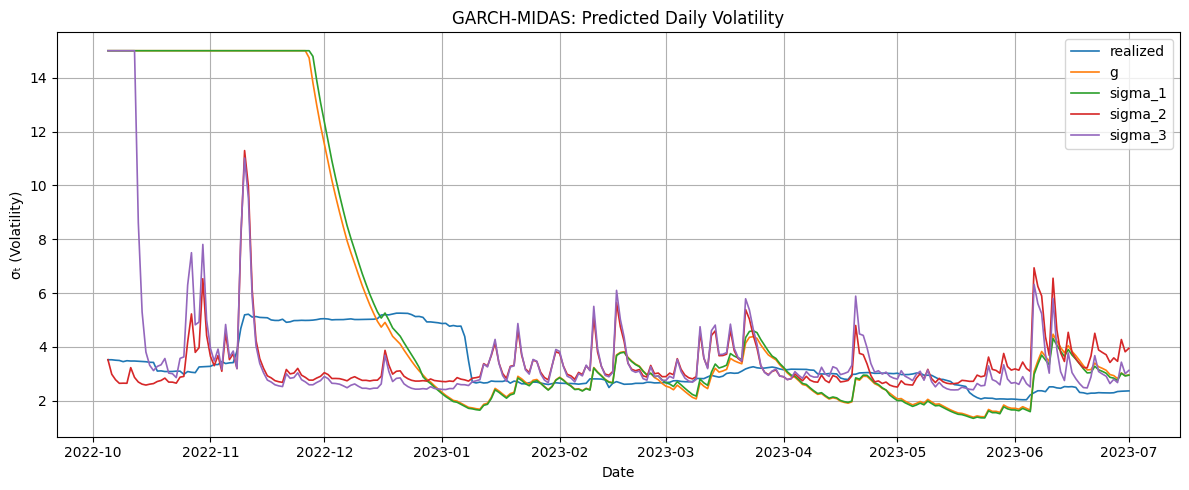

In [ ]:
# Test

garch_midas_visual(y_test, g_t, sigma2_t, sigma2_s_t, sigma2_ext_t)

In [ ]:
"""
We now have two models:
- **Baseline**: τₜ derived from M2 only
- **Enhanced**: τₜ derived from a combination of M2 and sentiment
"""
# --- 6. Model Evaluation: Likelihood, AIC, and QLIKE ---
def pseudo_loglik(returns, *sigma2):
    K = 6*30
    aic_set = {}

    for i, s in enumerate(sigma2, start=1):
        colname = f"sigma_{i}"
        residuals = returns**2 / s + np.log(s)
        ll = -0.5 * residuals.sum()
        aic = -2 * ll + 2 * K
        aic_set[colname] = aic.round(4)

    return aic_set


def QLIKE_loss(returns, *sigma2):
    qlike_set = {}

    for i, s in enumerate(sigma2, start=1):
        colname = f"sigma_{i}"
        qlike = np.mean(np.log(s) + (returns ** 2) / s)
        qlike_set[colname] = qlike.round(4)

    return qlike_set


aic_set = pseudo_loglik(returns_train, sigma2, sigma2_s, sigma2_ext)
print("AIC:", aic_set)
qlike_set = QLIKE_loss(returns_train, sigma2, sigma2_s, sigma2_ext)
print("QLIKE_Loss:", qlike_set)

AIC: {'sigma_1': np.float64(-6029.2518), 'sigma_2': np.float64(-6324.9482), 'sigma_3': np.float64(-6121.7655)}
QLIKE_Loss: {'sigma_1': np.float64(-5.6194), 'sigma_2': np.float64(-5.5111), 'sigma_3': np.float64(-5.5542)}


In [ ]:
# Test
aic_set_t = pseudo_loglik(returns_test, sigma2_t, sigma2_s_t, sigma2_ext_t)
print("AIC:", aic_set_t)
qlike_set_t = QLIKE_loss(returns_test, sigma2_t, sigma2_s_t, sigma2_ext_t)
print("QLIKE_Loss:", qlike_set_t)

AIC: {'sigma_1': np.float64(-1248.9317), 'sigma_2': np.float64(-1257.4928), 'sigma_3': np.float64(-1325.7349)}
QLIKE_Loss: {'sigma_1': np.float64(-5.3631), 'sigma_2': np.float64(-5.6754), 'sigma_3': np.float64(-6.2435)}


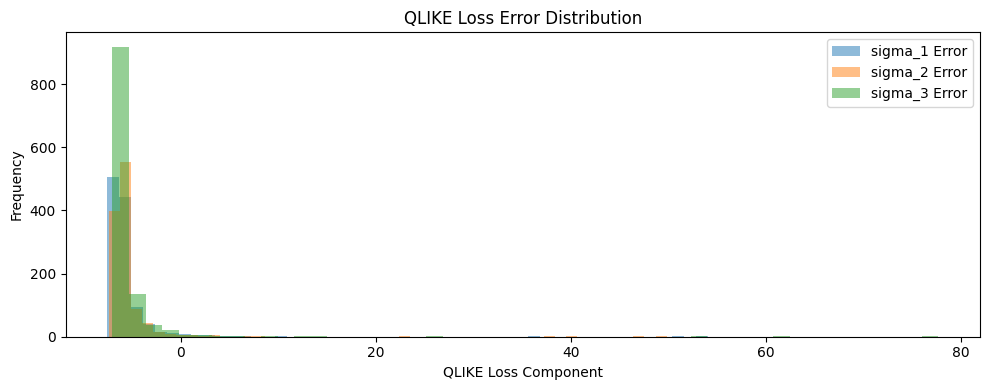

'\nInterpretation:\n- The distribution shows how QLIKE error components differ between the baseline and sentiment-augmented models.\n- A leftward shift or tighter clustering of the sentiment-enhanced distribution indicates improved model performance\n  (i.e., lower volatility forecast error).\n'

In [ ]:

def QLIKE_Loss_dist(returns, *sigma2):
    error_df = {}
    for i, s in enumerate(sigma2, start=1):
        colname = f"sigma_{i}"
        error_df[colname] = np.log(s) + (returns ** 2) / s

    error_df = pd.DataFrame(error_df).dropna()
    plt.figure(figsize=(10, 4))

    for e in error_df.columns:
        plt.hist(error_df[e], bins=50, alpha=0.5, label=f'{e} Error')
        plt.title("QLIKE Loss Error Distribution")
        plt.xlabel("QLIKE Loss Component")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()

    plt.show()

QLIKE_Loss_dist(returns_train, sigma2, sigma2_s, sigma2_ext)
"""
Interpretation:
- The distribution shows how QLIKE error components differ between the baseline and sentiment-augmented models.
- A leftward shift or tighter clustering of the sentiment-enhanced distribution indicates improved model performance
  (i.e., lower volatility forecast error).
"""


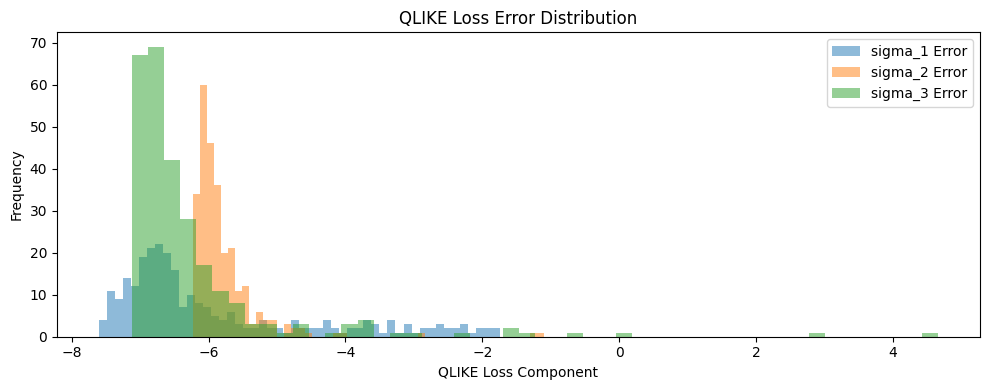

In [ ]:
# Test
QLIKE_Loss_dist(returns_test, sigma2_t, sigma2_s_t, sigma2_ext_t)

In [ ]:
# OOS
tau_series_v = compute_tau_series(midas_valid_1['M2'], theta1, theta2, K=6*30)
sigma2_v, sigma_v, g_v, returns_v = garch_midas_cal(garch_valid, tau_series_v, garch_dict)

def load_test_data(midas_df, returns, sentiments, feat_names, sen_names):
    midas_df = midas_df[feat_names]
    sentiments = sentiments[sen_names]
    returns = returns.mean(axis=1)
    returns.name = 'mean_returns'
    midas_df_new = pd.concat([midas_df, sentiments], axis=1) # New MIDAS df
    midas_df_new = midas_df_new.resample('D').ffill().reindex(returns.index)
    aligned_data = pd.concat([midas_df_new, returns], axis=1).dropna()
    midas_df_aligned = aligned_data[midas_df_new.columns]
    returns_aligned = aligned_data[returns.name]

    return midas_df_new, returns

midas_df_v_1, garch_df_v_1 = load_test_data(midas_valid, garch_valid, sentiments_valid, feat_names_1, sen_names_1)
midas_df_v_2, garch_df_v_2 = load_test_data(midas_valid, garch_valid, sentiments_valid, feat_names_2, sen_names_2)
sigma2_v1, sigma_v1, g2_v1 = build_sigma2_from_weights(w_auto_1, garch_df_v_1, midas_df_v_1,garch_midas_dict_1)
sigma2_v2, sigma_v2, g2_v2 = build_sigma2_from_weights(w_auto_2, garch_df_v_2, midas_df_v_2,garch_midas_dict_2)
common_idx = sigma_v1.index.intersection(sigma_v2.index)
common_idx = sigma_v.index.intersection(common_idx)
sigma_v1 = sigma_v1.loc[common_idx]
sigma_v2 = sigma_v2.loc[common_idx]
sigma_v = sigma_v.loc[common_idx]

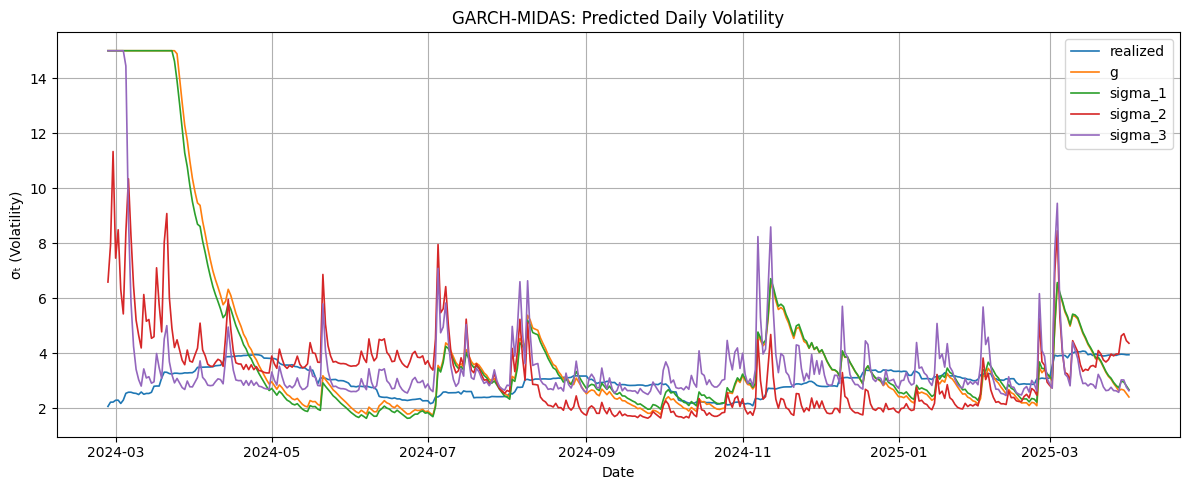

In [ ]:
# OOS
garch_midas_visual(garch_valid, g_v, sigma2_v, sigma2_v1, sigma2_v2)

In [ ]:
# OOS
aic_set = pseudo_loglik(garch_df_v_1, sigma2_v, sigma2_v1, sigma2_v2)
print("AIC:", aic_set)
qlike_set = QLIKE_loss(garch_df_v_1, sigma2_v, sigma2_v1, sigma2_v2)
print("QLIKE_Loss:", qlike_set)

AIC: {'sigma_1': np.float64(-2050.9652), 'sigma_2': np.float64(-2194.2149), 'sigma_3': np.float64(-2067.1124)}
QLIKE_Loss: {'sigma_1': np.float64(-6.0274), 'sigma_2': np.float64(-5.9263), 'sigma_3': np.float64(-6.0678)}


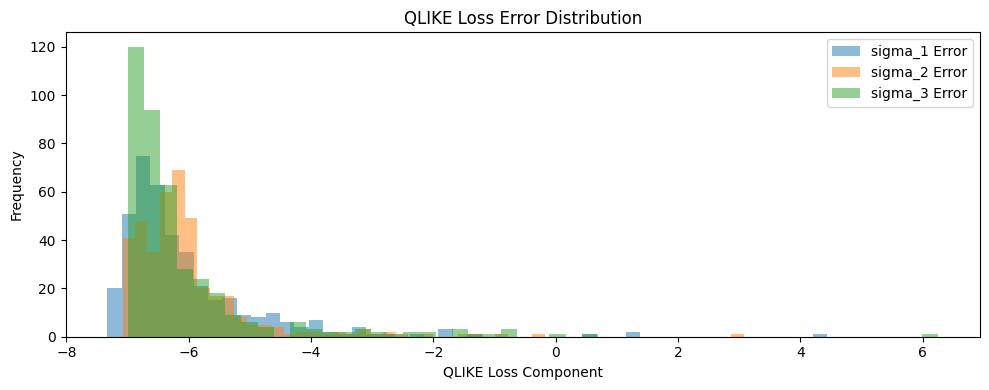

In [ ]:
# OOS
QLIKE_Loss_dist(garch_df_v_1, sigma2_v, sigma2_v1, sigma2_v2)

# Event Analysis
"""
This part implements a classical **event study** framework applied to crypto markets,
examining how cumulative abnormal returns (CAR) and cumulative realized volatility (CRV)
evolve around sentiment shocks (measured by `mp_label` derived from market sentiment data).

The method is directly grounded in academic finance literature such as:
- MacKinlay, A. C. (1997), "Event Studies in Economics and Finance" — foundational methodology.
- Cutler, Poterba & Summers (1989) — market reaction dynamics around macro news.
- Schwert (1981) — volatility clustering around event windows.
"""

In [ ]:
# 1. Preprocess sentiment data and assign event labels

def mp_sen_data_load(mp_og_data, returns):
    mp_daily = mp_og_data.dropna(subset=['date']).sort_values('date').copy()
    mp_daily['date'] = pd.to_datetime(mp_daily['date'])

    s = mp_daily['average_sentiment'].astype(float)
    mp_daily['mp_score'] = ((s - s.mean()) / (s.std(ddof=0) + 1e-12))

    q1, q2 = s.quantile([0.33, 0.66])
    def to_label(v):
        if v <= q1:  return 0
        if v >= q2:  return 2
        return 1
    mp_daily['mp_label'] = s.apply(to_label).astype(int)

# 2. Prepare return series and align with event dates
    returns.index = pd.to_datetime(returns.index)
    pre, post = 3, 3
    idx = returns.index


    events = mp_daily[['date','mp_label','mp_score']].drop_duplicates('date')
    events = events[(events['date'] >= returns.index.min()) & (events['date'] <= returns.index.max())]

    valid_mask = events['date'].isin(idx)
    events_valid = events.loc[valid_mask].copy()
    returns_event = returns


    return pre, post, events_valid, events, returns_event

pre, post, events_valid, events, returns_event = mp_sen_data_load(daily_avg_mp, garch_df.mean(axis=1))

"""
Labeling the sentiment shocks in this way follows common event-study practice,
where categorical regimes (bad/neutral/good news) are defined based on empirical thresholds.
The event-study framework requires precise alignment between event dates
and available return series. Only events with valid return data are kept.
"""
print(f"Incidents：{len(events_valid)} / {len(events)}")



Incidents：59 / 59


In [ ]:
# 3. Compute rolling average return as expected return benchmark
"""
The 28-day rolling mean serves as a proxy for the 'normal' expected return,
allowing calculation of abnormal returns (AR) as deviations from this baseline.
"""

def event_aligned_matrices(returns, events_valid, pre, post):
    rv = returns.abs()

    roll_mean = returns.rolling(28, min_periods=10).mean()

# 4. Define a helper function to extract event windows
    def get_window(series, center_date, pre=3, post=3):

        if center_date not in series.index:
            return None
        pos = series.index.get_loc(center_date)
        left = max(0, pos - pre)
        right = min(len(series)-1, pos + post)
        win = series.iloc[left:right+1]

        rel = np.arange(-pre, post+1)

        rel_index = np.arange(left - pos, right - pos + 1)
        out = pd.Series(np.nan, index=rel)
        out.loc[rel_index] = win.values
        return out
# 5. Build event-aligned matrices for abnormal returns and realized volatility
    wins_ret, wins_abret, wins_rv, labels = [], [], [], []
    for _, row in events_valid.iterrows():
        d = row['date']
        r_win   = get_window(returns, d, pre, post)
        base_win= get_window(roll_mean, d, pre, post)
        rv_win  = get_window(rv, d, pre, post)
        if r_win is None or base_win is None or rv_win is None:
            continue
        wins_ret.append(r_win.values)
        wins_abret.append((r_win - base_win).values)
        wins_rv.append(rv_win.values)
        labels.append(row['mp_label'])

    W_ret   = np.vstack(wins_ret)       if wins_ret   else np.empty((0, pre+post+1))
    W_abret = np.vstack(wins_abret)     if wins_abret else np.empty((0, pre+post+1))
    W_rv    = np.vstack(wins_rv)        if wins_rv    else np.empty((0, pre+post+1))
    labels  = np.array(labels)

    rel_days = np.arange(-pre, post+1)

    return W_abret, W_rv, labels, rel_days

W_abret, W_rv, labels, rel_days = event_aligned_matrices(garch_df.mean(axis=1), events_valid, pre, post)
"""
This extracts a symmetric event window (e.g., [-3, +3]) around each event.
The relative indexing (t=-3,...,t=+3) is a standard event-study technique
for aggregating reactions across multiple events.
"""

'\nThis extracts a symmetric event window (e.g., [-3, +3]) around each event.\nThe relative indexing (t=-3,...,t=+3) is a standard event-study technique\nfor aggregating reactions across multiple events.\n'

In [ ]:
"""
Matrices W_abret and W_rv contain event-aligned abnormal returns and realized volatility
for all events, enabling group-level averaging and hypothesis testing.
"""
# 6. Summarize CAR and CRV by event type
def CAR_CRV_cal(W_abret, W_rv, labels, rel_days):

    def summarize_group(mat, labels, k):
        if mat.shape[0] == 0:
            return None, 0
        sel = (labels == k)
        if sel.sum() == 0:
            return None, 0
        mean_path = np.nanmean(mat[sel], axis=0)
        cum_path = np.nancumsum(mean_path)
        return cum_path, sel.sum()

    CAR = {}
    CRV = {}
    counts = {}

    for k, name in zip([0,1,2], ["neg","neu","pos"]):
        CAR[name], counts[name] = summarize_group(W_abret, labels, k)
        CRV[name], _            = summarize_group(W_rv,    labels, k)

    return {
        "CAR": CAR,
        "CRV": CRV,
        "counts": counts,
        "rel_days": rel_days
    }

results = CAR_CRV_cal(W_abret, W_rv, labels, rel_days)

print(f"Incidents：neg={results['counts']['neg'] }, neu={results['counts']['neu']}, pos={results['counts']['pos'] }")
"""
CAR (Cumulative Abnormal Return) and CRV (Cumulative Realized Volatility)
are key metrics in event-study analysis. CAR measures price reaction magnitude,
while CRV captures changes in volatility structure around events.
"""

Incidents：neg=17, neu=12, pos=30


'\nCAR (Cumulative Abnormal Return) and CRV (Cumulative Realized Volatility)\nare key metrics in event-study analysis. CAR measures price reaction magnitude,\nwhile CRV captures changes in volatility structure around events.\n'

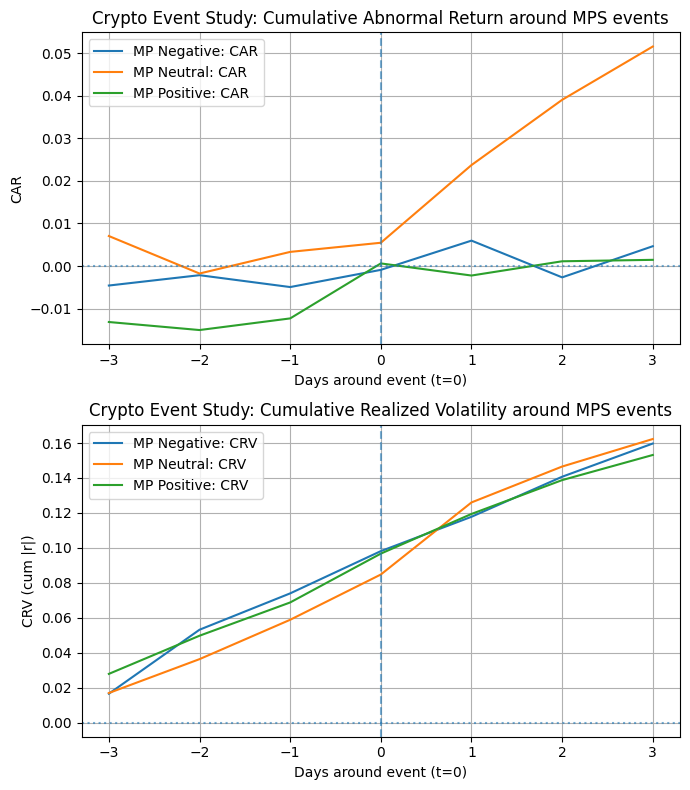

In [ ]:
def CAR_n_CRV_visual(rel_days, results):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))
    CAR_neg = results['CAR']['neg']
    CAR_neu = results['CAR']['neu']
    CAR_pos = results['CAR']['pos']
    if CAR_neg is not None: ax1.plot(rel_days, CAR_neg, label='MP Negative: CAR')
    if CAR_neu is not None: ax1.plot(rel_days, CAR_neu, label='MP Neutral: CAR')
    if CAR_pos is not None: ax1.plot(rel_days, CAR_pos, label='MP Positive: CAR')
    ax1.axvline(0, linestyle='--', alpha=0.6)
    ax1.axhline(0, linestyle=':', alpha=0.6)
    ax1.set_title('Crypto Event Study: Cumulative Abnormal Return around MPS events')
    ax1.set_xlabel('Days around event (t=0)')
    ax1.set_ylabel('CAR')
    ax1.legend()
    ax1.grid(True)

    CRV_neg = results['CRV']['neg']
    CRV_neu = results['CRV']['neu']
    CRV_pos = results['CRV']['pos']
    if CRV_neg is not None: ax2.plot(rel_days, CRV_neg, label='MP Negative: CRV')
    if CRV_neu is not None: ax2.plot(rel_days, CRV_neu, label='MP Neutral: CRV')
    if CRV_pos is not None: ax2.plot(rel_days, CRV_pos, label='MP Positive: CRV')
    ax2.axvline(0, linestyle='--', alpha=0.6)
    ax2.axhline(0, linestyle=':', alpha=0.6)
    ax2.set_title('Crypto Event Study: Cumulative Realized Volatility around MPS events')
    ax2.set_xlabel('Days around event (t=0)')
    ax2.set_ylabel('CRV (cum |r|)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

CAR_n_CRV_visual(rel_days, results)

In [ ]:
# 8. Hypothesis testing: compare abnormal returns after negative vs. positive shocks
def stats_result(W_abret, labels):
    from scipy.stats import ttest_ind
    def pick_at(mat, labels, k, offset):
        sel = (labels==k)
        if sel.sum()==0: return np.array([])
        return mat[sel, pre+offset]  # offset: -3..+3

    ab_neg_t1 = pick_at(W_abret, labels, 0, +1)
    ab_pos_t1 = pick_at(W_abret, labels, 2, +1)
    if len(ab_neg_t1)>1 and len(ab_pos_t1)>1:
        t_stat, p_val = ttest_ind(ab_neg_t1, ab_pos_t1, equal_var=False, nan_policy='omit')

    return t_stat, p_val

t_stat, p_val = stats_result(W_abret, labels)
print(f"t=+1 abnormal returns：Neg vs Pos  t={t_stat:.2f}, p={p_val:.2f}")
"""
A two-sample t-test compares post-event abnormal returns across sentiment types.
Statistical significance here suggests that negative sentiment shocks may induce
larger price adjustments than positive ones — consistent with behavioral finance findings
on asymmetric investor reactions (Baker & Wurgler, 2006).
"""

t=+1 abnormal returns：Neg vs Pos  t=1.21, p=0.23


'\nA two-sample t-test compares post-event abnormal returns across sentiment types.\nStatistical significance here suggests that negative sentiment shocks may induce\nlarger price adjustments than positive ones — consistent with behavioral finance findings\non asymmetric investor reactions (Baker & Wurgler, 2006).\n'

# Strategy Overview

This strategy is a systematic multi-asset crypto trading framework that integrates time-series momentum, volatility-conditioned exposure scaling, event-driven signal conditioning, and realistic cost-adjusted return modeling. Rebalancing occurs every *n* days, aligning signal generation and return realization to a consistent short-horizon holding structure.

---

## 1. Cost-Adjusted True Returns

**Purpose:** Ensure that backtested performance reflects executable net returns under realistic market frictions.

**Implementation:**

- Entry cost = commission + slippage applied at next-day open  
- Exit cost = commission + slippage applied at open *(n+1)* days ahead  
- Funding cost = daily perpetual rate × holding period (*n*)  
- True return = gross open-to-open return − total trading cost  

This transforms theoretical price returns into economically realizable PnL.

---

## 2. Time-Series Momentum via Donchian Breakout

Rather than cross-sectional ranking, the strategy applies a **Donchian channel breakout rule** to each asset individually:

- Upper band = rolling maximum (20 days)
- Lower band = rolling minimum (20 days)

Signal construction:

- Price > upper band → Long (+1)  
- Price < lower band → Short (−1)  
- Otherwise → Maintain previous directional bias  

This captures short-horizon trend persistence at the individual asset level, consistent with time-series momentum literature.

---

## 3. Volatility-Conditioned Exposure Scaling

Exposure is dynamically scaled using an external volatility estimate (e.g., GARCH-MIDAS long-run component).

Steps:

1. Compute rolling mean and standard deviation (30-day window).  
2. Convert volatility to a z-score.  
3. Apply logistic transformation:

$$
\sigma_{adjustment} = 0.5 + 0.8 \cdot \left(1 - \text{expit}(a \cdot z)\right)
$$

**Interpretation:**

- High volatility → reduced exposure  
- Low volatility → increased exposure  

This mechanism mitigates drawdowns during volatility spikes and improves risk-adjusted performance.

---

## 4. Event-Driven Signal Conditioning

Monetary policy events modify position sizes for three days following the announcement.

For each event:

- Day +1 to Day +3 adjustments  
- Negative sentiment → mild decay in exposure  
- Positive sentiment → stronger exposure reduction  
- Neutral → no adjustment  

Adjustment decays linearly across the three-day window.

This accounts for post-event uncertainty dynamics and volatility clustering documented in event-study literature.

---

## 5. Final Signal Construction

$$
\text{Final Signal} = \text{Momentum Signal} \times \text{Event Adjustment} \times \text{Volatility Scaling}
$$

Returns are realized on the same *n*-day horizon as the rebalancing schedule.

---

## 6. Portfolio Construction

- Portfolio return = equal-weight average of (true returns × final signal)  
- NAV = cumulative product of (1 + portfolio return)  
- Benchmark = CMC200 index open-to-open *n*-day return  

Performance comparison evaluates whether volatility-aware and event-adjusted exposure improves risk-adjusted returns relative to passive crypto market exposure.

---

# Summary

This framework integrates:

- Time-series momentum via Donchian breakout  
- Dynamic volatility scaling  
- Event-conditioned exposure adjustments  
- Full transaction cost and funding modeling  
- Equal-weight cross-asset aggregation  

Together, these elements form a disciplined, short-horizon crypto trading system designed to operate under realistic market conditions and adapt to both volatility regimes and macro-driven risk shocks.

In [ ]:
# Trading
"""
This trading strategy integrates time-series momentum, volatility scaling,
event-driven signal adjustments, and cost-aware position sizing into a
unified crypto multi-asset framework. It draws from well-established
academic foundations and is designed for robust performance under
realistic trading conditions.
"""
# start_date = '2019-04-10'
# end_date = '2025-04-10'
n = 2
sigma_ext = sigma_v1
start_date = sigma_ext.index[int(len(sigma_ext.index)*0.5)+1]
end_date = sigma_ext.index[-1] #int(len(sigma_s_t.index)*0.5) int(len(sigma_v1.index)*0.5) | sigma_t/sigma_v
# The strategy is able to generate good profits when n = 2 and 4. RERUN ALL THE CODE WHEN YOU CHANGE THE NUMBER IN "N"!!!!!
def backtesting(n, open_series, close_series, sigma_ext, start_date, end_date):

    open_series = open_series.loc[start_date:end_date]
    close_series = close_series.loc[start_date:end_date]
    events_1 = events.copy()
    events_1.set_index('date',drop=True,inplace=True)
    events_1 = events_1.loc[start_date:end_date]
    fee_rate = 0.0005   # 0.05% per side
    slippage_rate = 0.0002  # 0.02% per side
    funding_rate_daily = 0.0002  # 0.02% per day

    CMC200_open_in = open_series['crypto_index'].shift(-1)
    CMC200_open_out = open_series['crypto_index'].shift(-n-1)

    CMC200_crypto_returns = (CMC200_open_out - CMC200_open_in) / CMC200_open_in
    CMC200_crypto_returns = CMC200_crypto_returns[::n] # benchmark

    open_series = open_series[close_series.columns.to_list()] # to align

    entry_commission = (fee_rate + slippage_rate) * open_series.shift(-1)
    exit_commission = (fee_rate + slippage_rate) * open_series.shift(-n-1)
    funding_cost = funding_rate_daily * n * open_series
    trading_cost = entry_commission + exit_commission + funding_cost
    open_series_pct = (trading_cost / open_series)
    crypto_r = ((open_series.shift(-n-1) / open_series.shift(-1)) - 1) - open_series_pct # True Returns
    def donchian_signal(price_df, window=20):

        upper = price_df.rolling(window).max()
        lower = price_df.rolling(window).min()

        long_signal = (price_df > upper).astype(int)
        short_signal = (price_df < lower).astype(int)

        direction = long_signal - short_signal  # long=1, short=1 → 1 - 0 = +1 / 0 - 1 = -1
        direction = direction.replace(0, np.nan).ffill().fillna(0)
        direction = direction.apply(lambda s: np.where(s >= 0, 1, -1))
        direction = pd.DataFrame(direction, index=price_df.index, columns=price_df.columns)

        return direction

    signal_1 = donchian_signal(close_series, window=20)
    returns = crypto_r[::n] * signal_1[::n]
    returns = (returns.sum(axis=1) / len(returns.columns.to_list())) # Unadjusted

    full_index = pd.date_range(start=start_date, end=end_date, freq='D')
    sigma_ext_filled = sigma_ext.reindex(full_index)
    sigma_ext = sigma_ext_filled.reindex(signal_1.index).ffill()

    from scipy.special import expit
    a, k = 0.8, 0.6
    midas_mean = sigma_ext.rolling(30).mean() ##
    midas_std = sigma_ext.rolling(30).std()
    sigma_zscore = (sigma_ext - midas_mean) / midas_std
    sigma_adjustment = 0.5 + 0.8 * (1 - expit(a * sigma_zscore)) # 1 - expit(a * sigma_zscore) or -a * sigma_zscore
    sigma_adjustment = sigma_adjustment.fillna(1).reindex(signal_1.index)

#This scaling mechanism reduces exposure during volatility spikes and increases it
#when conditions are calmer. This improves risk-adjusted returns and controls drawdowns.

# for event adjustment
# 4. Event-Driven Signal Conditioning
# Adjust signals based on labeled macro events (MacKinlay, 1997).
    signal_2 = signal_1.copy()
    event_window = 3

    for date, mp_label in zip(events_1.index, events_1['mp_label']):

        for lag in range(1, event_window + 1):
            day = date + pd.Timedelta(days=lag)
            if day in signal_2.index:
                if mp_label == 0:  # Negative
                    adj = 1 - 0.05 * lag
                elif mp_label == 2:  # Positive
                    adj = 1 - 0.15 * lag
                else:
                    adj = 1
                signal_2.loc[day] *= adj

    signal_3 = signal_2.mul(sigma_adjustment,axis=0)
    adjusted_returns = crypto_r[::n] * signal_3[::n]
    adjusted_returns = (adjusted_returns.sum(axis=1) / len(adjusted_returns.columns.to_list()))



    NAV = (returns+1).cumprod(axis=0) - returns[0]
    Adjusted_NAV = (adjusted_returns+1).cumprod(axis=0) - adjusted_returns[0]
    CMC200_NAV = (CMC200_crypto_returns+1).cumprod(axis=0) - CMC200_crypto_returns[0]
    CMC200_NAV = CMC200_NAV.reindex(NAV.index).ffill()

    return {
        "NAV": NAV,
        "Adjusted_NAV": Adjusted_NAV,
        "CMC200_NAV": CMC200_NAV,
        "returns": returns,
        "adjusted_returns":adjusted_returns,
        "CMC200_crypto_returns": CMC200_crypto_returns,
        "signal_1":signal_1,
        "signal_2":signal_2,
        "signal_3":signal_3,
    }, sigma_ext_filled


results, sigma_ext_filled = backtesting(n, asset_open, garch_df,sigma_ext,start_date,end_date)
"""
Summary:
- Transaction costs ensure net returns reflect real-world execution. (Bianchi et al., 2022)
- Time-series momentum exploits return persistence. (Moskowitz et al., 2012)
- Volatility scaling improves Sharpe ratios and stability. (Barroso & Santa-Clara, 2015)
- Event adjustments account for macro shocks. (MacKinlay, 1997)
- Volatility normalization supports balanced risk allocation. (Maillard et al., 2010)

Together, these components form a systematic crypto trading strategy with strong academic grounding,
designed to outperform passive benchmarks under realistic market conditions.
"""
# Revisiting event study designs: robust and efficient estimation
# volatility clustering (academic source)

/tmp/ipython-input-1027666289.py:92: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  signal_2.loc[day] *= adj
/tmp/ipython-input-1027666289.py:92: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  signal_2.loc[day] *= adj
/tmp/ipython-input-1027666289.py:92: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  signal_2.loc[day] *= adj
/tmp/ipython-input-1027666289.py:92: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future ve

'\nSummary:\n- Transaction costs ensure net returns reflect real-world execution. (Bianchi et al., 2022)\n- Time-series momentum exploits return persistence. (Moskowitz et al., 2012)\n- Volatility scaling improves Sharpe ratios and stability. (Barroso & Santa-Clara, 2015)\n- Event adjustments account for macro shocks. (MacKinlay, 1997)\n- Volatility normalization supports balanced risk allocation. (Maillard et al., 2010)\n\nTogether, these components form a systematic crypto trading strategy with strong academic grounding,\ndesigned to outperform passive benchmarks under realistic market conditions.\n'

/tmp/ipython-input-2221774137.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  CMC200_NAV.plot(grid=True, color='tomato',label='Final NAV of CMC200 Crypto Index: {:.2f}'.format((CMC200_crypto_returns+1).prod() - CMC200_crypto_returns[0]))
/tmp/ipython-input-2221774137.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Adjusted_NAV.plot(grid=True, color='maroon',label='Final NAV : {:.2f}'.format((adjusted_returns+1).prod()- adjusted_returns[0]))
/tmp/ipython-input-2221774137.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated

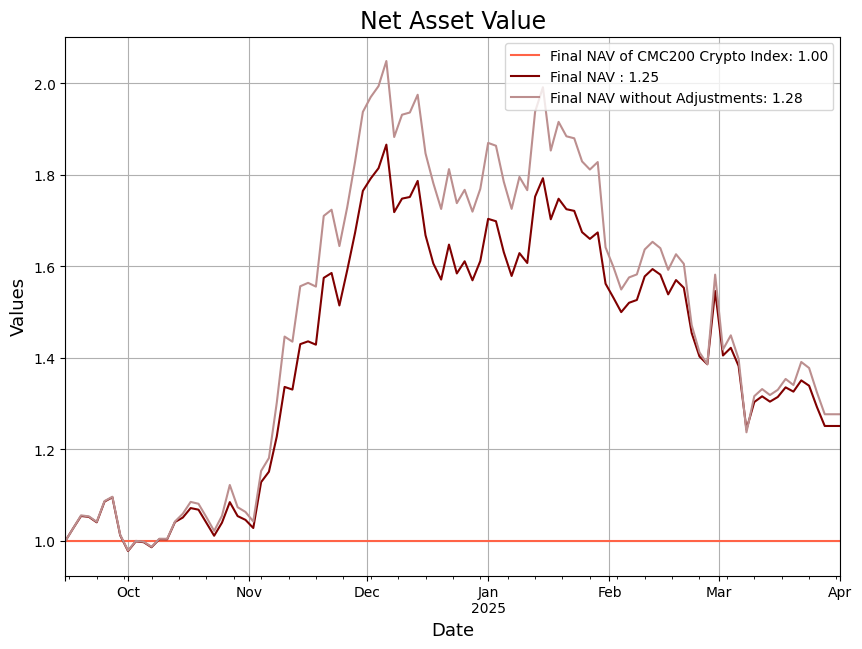

In [ ]:
def NVA_visual(results):
    CMC200_crypto_returns = results["CMC200_crypto_returns"]
    adjusted_returns = results["adjusted_returns"]
    returns = results["returns"]
    CMC200_NAV = results["CMC200_NAV"]
    Adjusted_NAV = results["Adjusted_NAV"]
    NAV = results["NAV"]
    plt.figure(figsize=(10,7))
    plt.title("Net Asset Value",fontsize=17)
    plt.xlabel("Date",fontsize=13)
    plt.ylabel("Values",fontsize=13)

    CMC200_NAV.plot(grid=True, color='tomato',label='Final NAV of CMC200 Crypto Index: {:.2f}'.format((CMC200_crypto_returns+1).prod() - CMC200_crypto_returns[0]))
    Adjusted_NAV.plot(grid=True, color='maroon',label='Final NAV : {:.2f}'.format((adjusted_returns+1).prod()- adjusted_returns[0]))
    NAV.plot(grid=True, color='rosybrown',label='Final NAV without Adjustments: {:.2f}'.format((returns+1).prod()- returns[0]))
    plt.legend()
    plt.show()

NVA_visual(results)

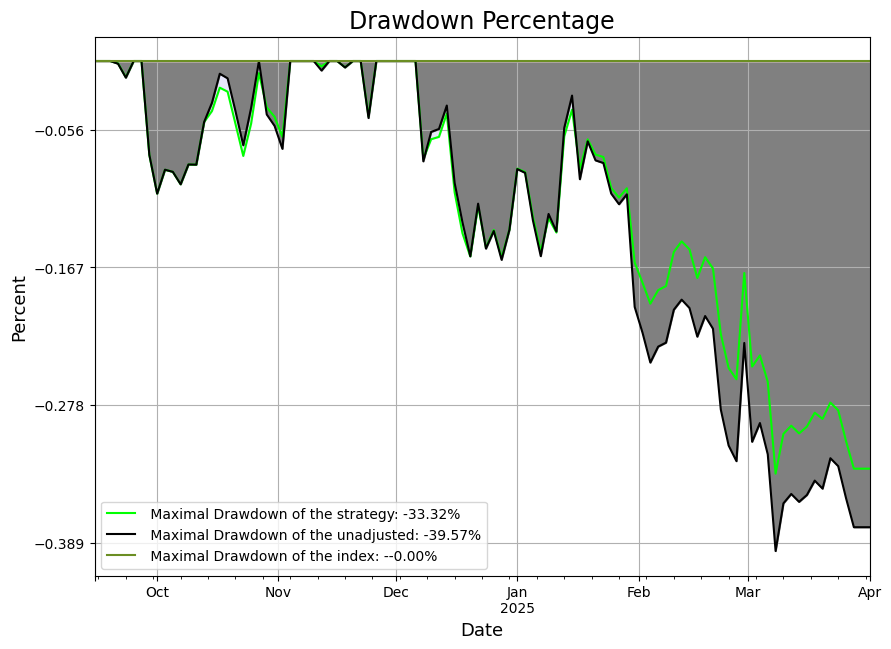

Frequency of the Strategy Drawdown Being Not Smaller than the Unadjusted: 0.23


In [ ]:
##### Drawdown test
def drawdown_visual(results):
    CMC200_crypto_returns = results["CMC200_crypto_returns"]
    adjusted_returns = results["adjusted_returns"]
    returns = results["returns"]

    NV = (adjusted_returns+1).cumprod(axis=0)
    running_maximum = np.maximum.accumulate(NV)

    for num in running_maximum:
        if num < 1:
            num = 1
        else:
            num = num

    drawdown = ((NV / running_maximum) - 1)
    max_drawdown = drawdown.min() * 100

    NV_0 = (returns+1).cumprod(axis=0)
    running_maximum_0 = np.maximum.accumulate(NV_0)

    for num in running_maximum_0:
        if num < 1:
            num = 1
        else:
            num = num

    drawdown_0 = ((NV_0 / running_maximum_0) - 1)
    max_drawdown_0 = drawdown_0.min() * 100

    NV_1 = (CMC200_crypto_returns+1).cumprod().ffill()
    running_maximum_1 = np.maximum.accumulate(NV_1)

    for num in running_maximum_1:
        if num > 1:
            num = 1
        else:
            num = num

    drawdown_1 = -((NV_1 / running_maximum_1) - 1)
    max_drawdown_1 = drawdown_1.max() * 100

    plt.title("Drawdown Percentage",fontsize=17)
    plt.ylabel("Percent",fontsize=13)
    plt.xlabel("Date",fontsize=13)
    drawdown.plot(figsize = (10,7), grid = True, color = 'lime', label = " Maximal Drawdown of the strategy: {:.2f}%".format(max_drawdown))
    drawdown_0.plot(figsize = (10,7), grid = True, color = 'black', label = " Maximal Drawdown of the unadjusted: {:.2f}%".format(max_drawdown_0))
    drawdown_1.plot(figsize = (10,7), grid = True, color = 'olivedrab', label = " Maximal Drawdown of the index: -{:.2f}%".format(max_drawdown_1))
    plt.legend()
    y_ticks = np.linspace(-0.5,0.5,10)
    plt.yticks(y_ticks)
    plt.fill_between(drawdown.index, drawdown, color='lavender')
    plt.fill_between(drawdown_0.index, drawdown_0, color='grey')
    plt.fill_between(drawdown_1.index, drawdown_1, color='mistyrose')
    plt.show()
    print('Frequency of the Strategy Drawdown Being Not Smaller than the Unadjusted: {:.2f}'.format(((drawdown < drawdown_0).sum()/len(drawdown.index))))

drawdown_visual(results)
# Usually the maximal drawdown rate in academic projects is over 25% (evidence wil be included)

Frequency of Adjusted Positions Being Larger than Unadjusted Positions: 0.09
Frequency of Adjusted Portfolio Return Being Not Smaller than Unadjusted Portfolio Return: 0.03


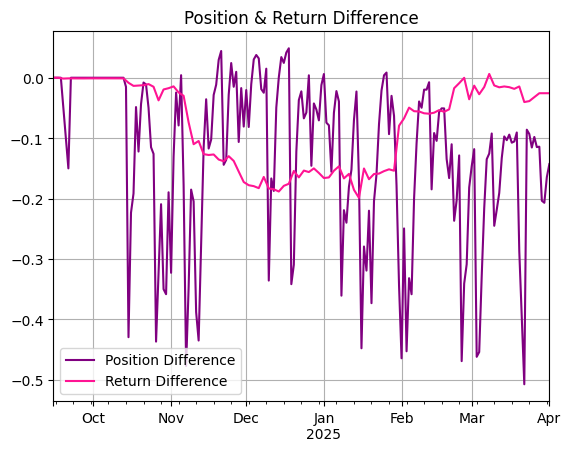

In [ ]:
def position_visual(results):
    signal_1 = results["signal_1"]
    signal_3 = results["signal_3"]
    adjusted_returns = results["adjusted_returns"]
    returns = results["returns"]
    signal_3_sum = (signal_3.abs()/len(signal_3.columns)).sum(axis=1)
    signal_1_sum = (signal_1.abs()/len(signal_1.columns)).sum(axis=1)
    position_diff = signal_3_sum - signal_1_sum
    return_diff = (adjusted_returns+1).cumprod(axis=0) - (returns+1).cumprod(axis=0)
    # return_diff = return_diff * 3
    (position_diff.clip(lower=-1, upper=1)).plot(grid=True, color='purple',label='Position Difference'.format((position_diff.iloc[-1])))
    (return_diff.clip(lower=-1, upper=1)).plot(grid=True, color='deeppink',label='Return Difference'.format((return_diff.iloc[-1])))
    print('Frequency of Adjusted Positions Being Larger than Unadjusted Positions: {:.2f}'.format(((position_diff > 0).sum())/position_diff.count())) # When signal_2 is not smaller than signal_1
    print('Frequency of Adjusted Portfolio Return Being Not Smaller than Unadjusted Portfolio Return: {:.2f}'.format(((return_diff >= 0).sum())/return_diff.count()))
    plt.legend()
    plt.title("Position & Return Difference")
    plt.show()

position_visual(results)
#Confidence intervals or t-test needed

In [ ]:
def measurements_cal(results, n):
    holding_period = n
    CMC200_crypto_returns = results["CMC200_crypto_returns"]
    adjusted_returns = results["adjusted_returns"]
    returns = results["returns"]

    print("Sharpe of the strategy: {:.2f}".format((adjusted_returns.mean()/adjusted_returns.std())*(252/holding_period)**0.5))
    print("Sharpe of the CMC200 Index: {:.2f}".format((CMC200_crypto_returns.mean()/CMC200_crypto_returns.std())*(252/holding_period)**0.5))
    print("Sharpe of the unleveraged: {:.2f}".format((returns.mean()/returns.std())*(252/holding_period)**0.5))
    hit_ratio = (adjusted_returns > 0).mean()
    print("Hit Ratio of the strategy: {:.2%}".format(hit_ratio))
    winning_returns = adjusted_returns[adjusted_returns > 0]
    losing_returns = adjusted_returns[adjusted_returns < 0]


    avg_win = winning_returns.mean()
    avg_loss = losing_returns.mean()


    payoff_ratio = avg_win / abs(avg_loss)

    print(f"Average Win: {avg_win:.4f}")
    print(f"Average Loss: {avg_loss:.4f}")
    print(f"Payoff Ratio: {payoff_ratio:.2f}")

measurements_cal(results, n)

Sharpe of the strategy: 0.86
Sharpe of the CMC200 Index: nan
Sharpe of the unleveraged: 0.85
Hit Ratio of the strategy: 50.00%
Average Win: 0.0327
Average Loss: -0.0277
Payoff Ratio: 1.18


/tmp/ipython-input-1672296773.py:8: RuntimeWarning: invalid value encountered in scalar divide
  print("Sharpe of the CMC200 Index: {:.2f}".format((CMC200_crypto_returns.mean()/CMC200_crypto_returns.std())*(252/holding_period)**0.5))
